<a href="https://colab.research.google.com/github/user2001230258/Pneumonia_Detection_ResNet/blob/main/resnet_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1 Import + Device + Mount drive
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from google.colab import drive

drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda


In [ ]:
!cp -r /content/drive/MyDrive/chest_xray /content/

In [ ]:
# 2 Load dataset
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    '/content/chest_xray/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    '/content/chest_xray/val',
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    '/content/chest_xray/test',
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
# 3 Load ResNet18 pretrained
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# 4 Freeze layers + fix FC
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 1),
    # nn.Sigmoid()
)

model = model.to(device)

In [ ]:
# 5 Training loop
# Khai báo pos_weight và criterion TRƯỚC vòng lặp để tối ưu tốc độ
pos_weight = torch.tensor([0.35]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
num_epochs = 15

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # 3 Bước cốt lõi đã được mở khóa
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/15] Loss: 0.1711
Epoch [2/15] Loss: 0.1196
Epoch [3/15] Loss: 0.1135
Epoch [4/15] Loss: 0.1047
Epoch [5/15] Loss: 0.1034
Epoch [6/15] Loss: 0.0920
Epoch [7/15] Loss: 0.0939
Epoch [8/15] Loss: 0.0909
Epoch [9/15] Loss: 0.0799
Epoch [10/15] Loss: 0.0859
Epoch [11/15] Loss: 0.0755
Epoch [12/15] Loss: 0.0869
Epoch [13/15] Loss: 0.0829
Epoch [14/15] Loss: 0.0786
Epoch [15/15] Loss: 0.0768


In [ ]:
# 6 Test accuracy
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        # preds = (outputs > 0.5).int().squeeze()
        # Thay vì preds = (outputs > 0.5).int()
        preds = (torch.sigmoid(outputs) > 0.5).int().squeeze()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"ResNet Accuracy: {accuracy:.2f}%")

ResNet Accuracy: 93.43%


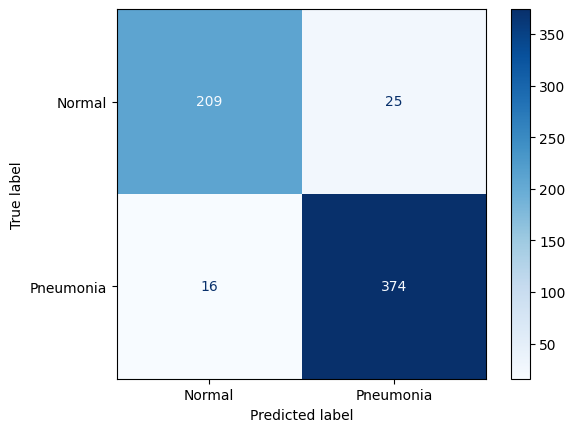

              precision    recall  f1-score   support

      Normal       0.93      0.89      0.91       234
   Pneumonia       0.94      0.96      0.95       390

    accuracy                           0.93       624
   macro avg       0.93      0.93      0.93       624
weighted avg       0.93      0.93      0.93       624



In [ ]:
# 7 Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        outputs = model(images)
        # preds = (outputs > 0.5).int().cpu().numpy()
        # Thay vì preds = (outputs > 0.5).int()
        preds = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()

        y_pred.extend(preds.flatten())
        y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Normal","Pneumonia"])
disp.plot(cmap="Blues")
plt.show()

# In ra các chỉ số Precision, Recall, F1-Score
print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

In [ ]:
# 8 Save model
save_path = "/content/drive/MyDrive/resnet_pneumonia_93_43.pth"
torch.save(model.state_dict(), save_path)
print(f"Đã lưu thành công mô hình vào: {save_path}")

Đã lưu thành công mô hình xịn nhất vào: /content/drive/MyDrive/resnet_pneumonia_93_43.pth


👇 Hãy bấm nút bên dưới để chọn một bức ảnh X-quang từ máy tính của bạn:


Saving IM-0061-0001.jpeg to IM-0061-0001.jpeg
Đã tải lên thành công: IM-0061-0001.jpeg


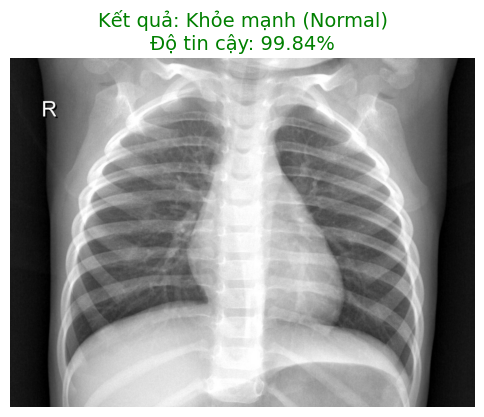

In [ ]:
# BƯỚC 1: Tự upload ảnh từ máy tính lên Colab
from google.colab import files
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

print("👇 Hãy bấm nút bên dưới để chọn một bức ảnh X-quang từ máy tính của bạn:")
uploaded = files.upload()

# Lấy tên file vừa upload
image_path = list(uploaded.keys())[0]
print(f"Đã tải lên thành công: {image_path}")

# BƯỚC 2: Tiền xử lý ảnh
demo_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img = Image.open(image_path).convert('RGB')
img_tensor = demo_transform(img).unsqueeze(0).to(device)

# BƯỚC 3: Dự đoán
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    prob = torch.sigmoid(output).item()

if prob > 0.5:
    label = "Viêm phổi (Pneumonia)"
    confidence = prob * 100
else:
    label = "Khỏe mạnh (Normal)"
    confidence = (1 - prob) * 100

# BƯỚC 4: Hiển thị kết quả
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Kết quả: {label}\nĐộ tin cậy: {confidence:.2f}%",
          fontsize=14, color='red' if prob > 0.5 else 'green')
plt.axis('off')
plt.show()